# Validation & Revenue Decomposition (GA4 Funnel)

1. Validated funnel consistency (no stage violations, totals match Power BI)

2. Calculated conversion rates across funnel stages

3. Decomposed revenue changes into Sessions, CVR, and AOV drivers (7-day vs prior 7-day)

In [1]:
import pandas as pd

In [12]:
#pip install google-cloud-bigquery pandas pyarrow
#!pip install db-dtypes pandas google-cloud-bigquery pyarrow

In [7]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="eastern-gravity-445921-h8")

query = """
SELECT *
FROM `eastern-gravity-445921-h8.temp.final_powerbi_dataset`
"""

df = client.query(query).to_dataframe()

df.head()

c:\Users\tbdp1\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_dt,device_category,traffic_source,country,session_key,view_item,add_to_cart,begin_checkout,purchase,revenue
0,2020-11-15,desktop,(direct),United States,1011845.30882218221712628167,0,0,0,0,0.0
1,2020-11-15,mobile,<Other>,India,1023953.9842241768834633041,0,0,0,0,0.0
2,2020-11-15,mobile,(direct),India,1023953.98422417684970143886,0,0,0,0,0.0
3,2020-11-15,desktop,<Other>,United States,1103734.1463717333842755686,0,0,0,0,0.0
4,2020-11-15,desktop,google,Australia,1104932.40204479398873846065,0,0,0,0,0.0


In [8]:
df.shape

(360974, 10)

In [9]:
df.columns

Index(['event_dt', 'device_category', 'traffic_source', 'country',
       'session_key', 'view_item', 'add_to_cart', 'begin_checkout', 'purchase',
       'revenue'],
      dtype='object')

In [6]:
df["revenue"].sum()
df["purchase"].sum()

98

## 1. Validate funnel metrics (sanity checks)

In [ ]:
# basic checks + totals
import numpy as np

print("Rows (sessions):", len(df))
print("Nulls per key column:")
display(df[["event_dt","view_item","add_to_cart","begin_checkout","purchase","revenue"]].isna().sum())

totals = {
    "View Item Sessions": int(df["view_item"].sum()),
    "Cart Sessions": int(df["add_to_cart"].sum()),
    "Checkout Sessions": int(df["begin_checkout"].sum()),
    "Purchase Sessions": int(df["purchase"].sum()),
    "Total Revenue": float(df["revenue"].sum()),
}
totals

Rows (sessions): 360974
Nulls per key column:


event_dt          0
view_item         0
add_to_cart       0
begin_checkout    0
purchase          0
revenue           0
dtype: int64

{'View Item Sessions': 77203,
 'Cart Sessions': 15225,
 'Checkout Sessions': 11123,
 'Purchase Sessions': 4851,
 'Total Revenue': 362165.0}

In [11]:
# logical funnel rule check (cart can’t exceed views, etc.)

violations = {
    "cart_gt_view": int((df["add_to_cart"] > df["view_item"]).sum()),
    "checkout_gt_cart": int((df["begin_checkout"] > df["add_to_cart"]).sum()),
    "purchase_gt_checkout": int((df["purchase"] > df["begin_checkout"]).sum()),
}
violations

{'cart_gt_view': 17, 'checkout_gt_cart': 5173, 'purchase_gt_checkout': 12}

## 2. Calculate conversion rates

In [13]:
# overall conversion rate

view_sessions = df["view_item"].sum()
cart_sessions = df["add_to_cart"].sum()
checkout_sessions = df["begin_checkout"].sum()
purchase_sessions = df["purchase"].sum()

view_to_cart = cart_sessions / view_sessions if view_sessions else np.nan
cart_to_checkout = checkout_sessions / cart_sessions if cart_sessions else np.nan
checkout_to_purchase = purchase_sessions / checkout_sessions if checkout_sessions else np.nan
overall_cvr = purchase_sessions / len(df) if len(df) else np.nan

pd.DataFrame({
    "Metric": ["View → Cart", "Cart → Checkout", "Checkout → Purchase", "Overall CVR (Purchase/Sessions)"],
    "Value": [view_to_cart, cart_to_checkout, checkout_to_purchase, overall_cvr]
}).assign(Value=lambda x: x["Value"].round(4))

,Metric,Value
0,View → Cart,0.1972
1,Cart → Checkout,0.7306
2,Checkout → Purchase,0.4361
3,Overall CVR (Purchase/Sessions),0.0134


The ecommerce funnel shows the following conversion behavior:

**View → Cart: 19.7%**
Only about 1 in 5 product viewers add an item to their cart, indicating the largest drop-off occurs at the product page stage. This may suggest opportunities to improve product descriptions, pricing competitiveness, or product presentation.

**Cart → Checkout: 73.1%**
A relatively high conversion rate from cart to checkout suggests that once users add items to their cart, most are motivated to continue toward purchase.

**Checkout → Purchase: 43.6%**
Less than half of users who start checkout complete the purchase. This could indicate friction during checkout, such as shipping costs, payment issues, or complex checkout flows.

**Overall Conversion Rate: 1.34%**
Across all sessions, approximately 1.34% of users complete a purchase, which is within the typical ecommerce range (1–3%).

In [14]:
# Conversion rates by ddevice

if "device_category" in df.columns:
    by_device = df.groupby("device_category", as_index=False).agg(
        sessions=("purchase", "size"),
        purchases=("purchase", "sum"),
        revenue=("revenue", "sum"),
        view=("view_item", "sum"),
        cart=("add_to_cart", "sum"),
        checkout=("begin_checkout", "sum"),
    )
    by_device["overall_cvr"] = by_device["purchases"] / by_device["sessions"]
    by_device["view_to_cart"] = by_device["cart"] / by_device["view"]
    by_device["cart_to_checkout"] = by_device["checkout"] / by_device["cart"]
    by_device["checkout_to_purchase"] = by_device["purchases"] / by_device["checkout"]
    display(by_device.sort_values("revenue", ascending=False))

,device_category,sessions,purchases,revenue,view,cart,checkout,overall_cvr,view_to_cart,cart_to_checkout,checkout_to_purchase
0,desktop,209458,2750,208815.0,44929,8818,6402,0.013129,0.196265,0.726015,0.429553
1,mobile,143500,1997,146768.0,30571,6086,4480,0.013916,0.199078,0.736116,0.445759
2,tablet,8016,104,6582.0,1703,321,241,0.012974,0.188491,0.750779,0.431535


**Desktop drives the most revenue**

Desktop generates $208,815 revenue, the highest among devices.

It also has the largest number of sessions (209K) and purchases (2,750).

This indicates that desktop remains the primary revenue channel.

**Mobile conversion is slightly higher**

Mobile overall conversion rate: 1.39%

Desktop overall conversion rate: 1.31%

Despite fewer sessions than desktop, mobile users convert slightly better, suggesting the mobile experience is effective in driving purchases.

***Funnel behavior is consistent across devices***

The conversion rates between funnel stages are very similar:

Stage	Range
View → Cart	~19–20%

Cart → Checkout	~72–75%

Checkout → Purchase	~43–45%

This indicates that user behavior patterns remain stable across devices, meaning there is no major device-specific friction point.

## 3. Revenue decomposition (Sessions x CVR x AOV)

In [15]:
# build daily table

# Make sure event_dt is a real date
df["event_dt"] = pd.to_datetime(df["event_dt"])

daily = df.groupby("event_dt", as_index=False).agg(
    sessions=("purchase", "size"),              # one row = one session in your dataset
    purchases=("purchase", "sum"),
    revenue=("revenue", "sum"),
)

daily["cvr"] = daily["purchases"] / daily["sessions"]
daily["aov"] = daily["revenue"] / daily["purchases"]

daily.tail()

,event_dt,sessions,purchases,revenue,cvr,aov
87,2021-01-27,4606,50,457.0,0.010855,9.14
88,2021-01-28,4228,56,128.0,0.013245,2.285714
89,2021-01-29,3799,51,190.0,0.013425,3.72549
90,2021-01-30,2908,28,159.0,0.009629,5.678571
91,2021-01-31,2849,18,0.0,0.006318,0.0


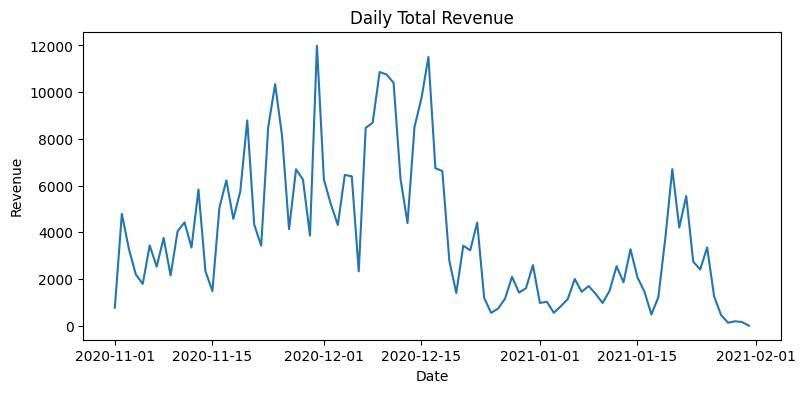

In [16]:
# plot revenue trend

import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(daily["event_dt"], daily["revenue"])
plt.title("Daily Total Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

Daily revenue peaks in early–mid December, followed by a sharp decline starting late December and continuing into January. This pattern likely reflects seasonal shopping behavior, where demand drops after the holiday period.

In [17]:
# decomposition of revenue changes

daily_sorted = daily.sort_values("event_dt").reset_index(drop=True)

if len(daily_sorted) < 14:
    raise ValueError("Need at least 14 days of data to compare last 7 vs previous 7.")

last7 = daily_sorted.tail(7).mean(numeric_only=True)
prev7 = daily_sorted.tail(14).head(7).mean(numeric_only=True)

# Revenue identity: Revenue = Sessions * CVR * AOV
rev_last = last7["sessions"] * last7["cvr"] * last7["aov"]
rev_prev = prev7["sessions"] * prev7["cvr"] * prev7["aov"]
delta = rev_last - rev_prev

# Stepwise decomposition (intuitive + portfolio-friendly)
sessions_effect = (last7["sessions"] - prev7["sessions"]) * prev7["cvr"] * prev7["aov"]
cvr_effect = last7["sessions"] * (last7["cvr"] - prev7["cvr"]) * prev7["aov"]
aov_effect = last7["sessions"] * last7["cvr"] * (last7["aov"] - prev7["aov"])

summary = pd.DataFrame({
    "Driver": ["Sessions", "Conversion Rate (CVR)", "Average Order Value (AOV)", "Total Change (approx)"],
    "Impact": [sessions_effect, cvr_effect, aov_effect, sessions_effect + cvr_effect + aov_effect]
})

results = {
    "Revenue (prev 7-day avg)": rev_prev,
    "Revenue (last 7-day avg)": rev_last,
    "Revenue change": delta
}

results, summary.assign(Impact=lambda x: x["Impact"].round(2))

({'Revenue (prev 7-day avg)': 3741.1972484764838,
  'Revenue (last 7-day avg)': 642.0935120400367,
  'Revenue change': -3099.103736436447},
                       Driver   Impact
 0                   Sessions  -154.17
 1      Conversion Rate (CVR)  -474.88
 2  Average Order Value (AOV) -2470.06
 3      Total Change (approx) -3099.10)

The revenue drop of ~$3,099 is primarily driven by a sharp decline in Average Order Value (AOV), which accounts for the largest impact (−$2,470). Smaller contributions come from lower conversion rate (−$475) and reduced sessions (−$154). This suggests the revenue decline was mainly caused by customers purchasing lower-value orders rather than a major traffic loss.

In [18]:
impacts = summary.set_index("Driver")["Impact"]
top_driver = impacts.drop("Total Change (approx)").abs().idxmax()
direction = "increased" if impacts[top_driver] > 0 else "decreased"

print(f"Revenue {direction} primarily due to changes in {top_driver}.")

Revenue decreased primarily due to changes in Average Order Value (AOV).
